
### The Information Plane on MNIST  —  does a network "compress" during training?

### WHAT THIS IS
------------
This reproduces the Information Bottleneck / "information plane" experiment
(Shwartz-Ziv & Tishby, 2017). We train a small MLP on MNIST and, for each hidden
layer T, track two mutual-information quantities over the course of training:

    I(X; T)  =  how much the layer still knows about the INPUT   (compression axis)
    I(T; Y)  =  how much the layer still knows about the LABEL    (relevance axis)

Plotting (I(X;T), I(T;Y)) per layer at many training checkpoints gives the
"information plane". The claimed dynamics are two phases:
    1. FITTING:     I(T;Y) rises (and I(X;T) rises) -> points move up-and-right.
    2. COMPRESSION: I(X;T) FALLS while I(T;Y) stays high -> points drift LEFT.
The compression phase is the thing this experiment is about.

### THE HONEST ANSWER (read before interpreting your plot)
-------------------------------------------------------
Whether you SEE compression is contested (Saxe et al., 2018) and depends on:
  * Activation function: saturating ones (tanh) tend to show compression;
    ReLU often shows little or none. Try both via ACTIVATION below.
  * Layer width: NARROW layers compress visibly; WIDE layers don't (their binned
    activations never collapse, so I(X;T) stays pinned at log2(N) and never moves).
  * Bin count: I(X;T) for a deterministic net is technically infinite, so the
    finite number you measure is entirely a function of the binning. Vary N_BINS
    and watch the trajectories move -> proof that the plane reflects the estimator
    as much as the learning.
So the defensible conclusion is: "this network compresses (in narrow saturating
layers), but the observation is sensitive to architecture and estimator."

### HOW WE ESTIMATE MI (binning) — the key reasoning
------------------------------------------------
We treat the input distribution as the EMPIRICAL set of N probe samples, each a
distinct symbol with probability 1/N. At a fixed checkpoint the network is
DETERMINISTIC, so T is a deterministic function of X. Therefore H(T|X) = 0 and:

        I(X; T) = H(T) - H(T|X) = H(T)

i.e. I(X;T) is just the entropy of the (binned) layer activations over the probe
set. "Compression" = many different inputs collapsing onto the SAME binned
pattern, which lowers H(T). I(T;Y) is computed from the joint histogram of
(binned pattern, label):  I(T;Y) = H(T) + H(Y) - H(T,Y).

In [18]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 0
HIDDEN_SIZES = [
    12,
    10,
    7,
    5,
]  # tiny layers -> patterns can collapse -> compression visible.
# Try [256, 128, 64] to see compression DISAPPEAR.
ACTIVATION = "tanh"  # "tanh" (shows compression) or "relu" (usually doesn't)
N_BINS = 30  # discretization granularity for the MI estimate
EPOCHS = 250
BATCH_SIZE = 256
LR = 0.06
MOMENTUM = 0.9  # SGD noise is part of the original compression story
TRAIN_N = 5000  # training subset (keeps CPU fast)
PROBE_N = 3000  # fixed set used for ALL MI measurements

torch.manual_seed(SEED)
np.random.seed(SEED)

### Dataset

In [19]:
#    The probe set MUST be the same images at every checkpoint so the trajectories
#    are comparable across epochs.
tf = transforms.ToTensor()
full = datasets.MNIST("./data", train=True, download=True, transform=tf)

train_loader = DataLoader(
    Subset(full, range(TRAIN_N)), batch_size=BATCH_SIZE, shuffle=True
)

probe = Subset(full, range(TRAIN_N, TRAIN_N + PROBE_N))
probe_x = torch.stack([probe[i][0] for i in range(len(probe))])  # [PROBE_N, 1, 28, 28]
probe_y = np.array([probe[i][1] for i in range(len(probe))])  # [PROBE_N]

In [20]:
full.classes, full[0][0].shape, full[0][1]

(['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'],
 torch.Size([1, 28, 28]),
 5)

### MODEL  — small MLP that EXPOSES each hidden layer's post-activation tensor.
- A normal classifier returns only logits; this experiment needs the T's.
- Hidden layers use the chosen activation; the OUTPUT has NO activation
- (CrossEntropyLoss expects raw logits and applies softmax internally).


In [21]:
from torch import nn

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_sizes, n_classes, activation="tanh"):
        super().__init__()
        self.flatten = nn.Flatten()
        sizes = [in_dim] + list(hidden_sizes) + [n_classes]
        self.lins = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i + 1]) for i in range(len(sizes) - 1)]
        )
        self.act = nn.Tanh() if activation == "tanh" else nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        activations = []  # the T's we will measure
        for i, lin in enumerate(self.lins):
            x = lin(x)
            if i < len(self.lins) - 1:  # hidden layer -> activate + record
                x = self.act(x)
                activations.append(x)
            # last layer: leave as raw logits
        return x, activations  # (logits, [T1, T2, ...])


### MUTUAL INFORMATION BY BINNING 

In [22]:
# - entropy(): Shannon entropy (bits) from a vector of counts. 
# - binned_mi(): returns (I(X;T), I(T;Y)) using the reasoning in the header. 
# - NOTE on range: tanh outputs live in (-1, 1) so we bin over [-1, 1]. 
# For ReLU  (range [0, inf)) we bin over the observed [min, max] instead, 
# otherwise every sample would fall in one bin. Pass lo/hi=None to auto-range from the data. 
def entropy(counts):
    p = counts / counts.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


def binned_mi(T, Y, n_bins=30, lo=None, hi=None):
    # T: [N, D] numpy activations for one layer.  Y: [N] integer labels.
    if lo is None:
        lo = float(T.min())
    if hi is None:
        hi = float(T.max())
    edges = np.linspace(lo, hi, n_bins + 1)
    binned = np.clip(np.digitize(T, edges[1:-1]), 0, n_bins - 1)  # [N, D] bin indices

    # Map each sample's vector of bin indices to a single "pattern id".
    _, ids = np.unique(binned, axis=0, return_inverse=True)
    ids = ids.ravel()

    H_T = entropy(np.bincount(ids))  # I(X;T) = H(T) (deterministic net)
    H_Y = entropy(np.bincount(Y))
    n_y = int(Y.max()) + 1
    H_TY = entropy(np.bincount(ids * n_y + Y))  # joint entropy of (pattern, label)

    I_XT = H_T
    I_TY = H_T + H_Y - H_TY
    return I_XT, I_TY


### TRAIN + CAPTURE

In [23]:
# Train normally on the logits. After each epoch, run the FIXED probe set
# through the net in eval/no_grad mode and record every layer's MI.
model = MLP(28 * 28, HIDDEN_SIZES, 10, activation=ACTIVATION)
opt = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
loss_fn = nn.CrossEntropyLoss()

# tanh -> bin over fixed (-1, 1); relu -> auto-range (lo=hi=None)
BIN_LO, BIN_HI = (-1.0, 1.0) if ACTIVATION == "tanh" else (None, None)


@torch.no_grad()
def capture_activations():
    model.eval()
    _, acts = model(probe_x)
    model.train()
    return [a.numpy() for a in acts]


plane = []  # rows of (epoch, layer_index, I_XT, I_TY)
for epoch in range(EPOCHS):
    for xb, yb in train_loader:
        logits, _ = model(xb)
        loss = loss_fn(logits, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()

    for li, T in enumerate(capture_activations()):
        i_xt, i_ty = binned_mi(T, probe_y, n_bins=N_BINS, lo=BIN_LO, hi=BIN_HI)
        plane.append((epoch, li, i_xt, i_ty))

plane = np.array(plane)
n_layers = len(HIDDEN_SIZES)


### PLOT THE INFORMATION PLANE

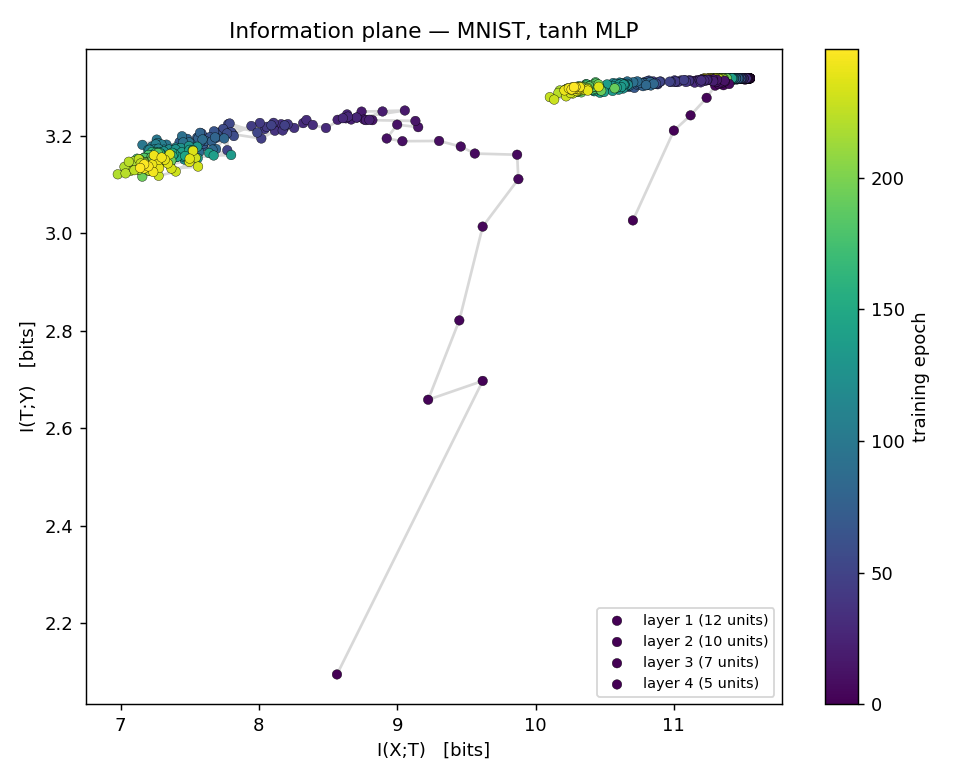

In [25]:
# x = I(X;T), y = I(T;Y). One trajectory per layer, colored by epoch.
# Early (dark) points to the RIGHT and late (yellow) points to the LEFT of them
# = compression.
from IPython.display import Image
fig, ax = plt.subplots(figsize=(7.5, 6))
for li in range(n_layers):
    pts = plane[plane[:, 1] == li]
    ax.plot(pts[:, 2], pts[:, 3], color="gray", alpha=0.3, zorder=1)
    sc = ax.scatter(
        pts[:, 2],
        pts[:, 3],
        c=pts[:, 0],
        cmap="viridis",
        s=28,
        edgecolor="k",
        linewidth=0.2,
        label=f"layer {li + 1} ({HIDDEN_SIZES[li]} units)",
        zorder=2,
    )
ax.set_xlabel("I(X;T)   [bits]")
ax.set_ylabel("I(T;Y)   [bits]")
ax.set_title(f"Information plane — MNIST, {ACTIVATION} MLP")
ax.legend(loc="lower right", fontsize=8)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("training epoch")
plt.tight_layout()
plt.savefig("information_plane.png", dpi=130)
Image("information_plane.png")


### NUMERIC SUMMARY  — did each layer's I(X;T) fall after its peak?

In [26]:
# A positive "drop" = the layer compressed (lost input info). Expect the
# largest drops in the narrowest/deepest layers.
print("layer | width | peak I(X;T) @ep | final I(X;T) | compression drop")
for li in range(n_layers):
    pts = plane[plane[:, 1] == li]
    xt = pts[:, 2]
    pk = int(xt.argmax())
    print(
        f"  {li + 1}   |  {HIDDEN_SIZES[li]:2d}   |  {xt[pk]:5.2f} @ ep{int(pts[pk, 0]):3d}  "
        f"|   {xt[-1]:5.2f}     |   {xt[pk] - xt[-1]:+.2f}"
    )

print(
    f"\nH(Y) = {entropy(np.bincount(probe_y)):.2f} bits  "
    f"(the most label info any layer could hold)"
)


layer | width | peak I(X;T) @ep | final I(X;T) | compression drop
  1   |  12   |  11.55 @ ep  0  |   11.29     |   +0.26
  2   |  10   |  11.55 @ ep  5  |   11.25     |   +0.30
  3   |   7   |  11.40 @ ep  6  |   10.28     |   +1.12
  4   |   5   |   9.88 @ ep  5  |    7.14     |   +2.73

H(Y) = 3.32 bits  (the most label info any layer could hold)


### EXPERIMENTS TO TRY (each changes the conclusion — that's the point)
-  ACTIVATION = "relu"          -> compression largely vanishes (Saxe et al.)
-  HIDDEN_SIZES = [256,128,64]  -> I(X;T) pinned at log2(PROBE_N), no movement
-  N_BINS = 10 vs 100           -> trajectories shift: the plane is estimator-dependent